# 03 — Blended LLM + ML (GPT-5.4 · tune / validate)

Can XGBoost and GPT-5.4 together beat either one alone on Charged-Off F1? Charged Off is the minority class, so that is the number worth moving.

The binary GPT-5.4 signal is recycled from Phase 1 (`01a`/`01c` predictions, with soft probabilities from `llm_calls.csv`), so it costs no API calls here. The only signal generated in this notebook is the 5A risk score, via OpenAI.

Every hyper-parameter is fit on `tuning` only; the winning strategy is then picked on `robustness` (validation), so the reported gains are held out rather than in-sample. Only `tuning` and `robustness` are loaded here. `test_batch` stays sealed and is scored once, in Phase 4.

| Sample | Role | Used for |
|--------|------|----------|
| `tuning_sample` | train / tune | grid-search every blend hyper-parameter (α, threshold, gate band) |
| `robustness_batch` | validation | pick the winning strategy (locked params) |
| `test_batch` | test, held out | scored only in Phase 4 |

### LLM signals per loan
1. Binary: the `no_desc` default prompt (the Phase-1 winner by robustness), recycled from Phase 1 with no API calls.
2. 5A risk score: borrower description text only, mapped to a 0–10 risk (Best-of-N self-consistency), generated here via OpenAI.

### Strategies on the leaderboard
Hard-label rules (union / intersection / boost / prune), soft blend on the binary signal, confidence gate, risk-score blend (5A), and an optional sentence-embedding blend.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import re
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score, confusion_matrix,
)

from llm_utils import (
    run_ml_on_sample, evaluate_predictions, call_llm, load_api_key,
    parse_llm_response, build_system_prompt, build_user_prompt,
    format_loan_features, FEATURE_DESCRIPTIONS,
    RESULTS_DIR, DATA_DIR, MODEL_DIR,
)

# ── LLM provider ──────────────────────────────────────────────────────────────
LLM_PROVIDER = 'openai'
LLM_MODEL    = 'gpt-5.4'

# Best-of-N self-consistency for the numeric risk scorer (Wang et al., 2022):
# sample N times at low temperature, average the scores → lower single-call variance.
BON_N    = 1
BON_TEMP = 0.3

# Set True to ignore cached signal CSVs and recompute (recycle binary / re-call OpenAI for 5A).
FORCE_REGEN = False


def metrics_dict(name, y_true, y_pred):
    yt = np.asarray(y_true)
    yp = np.asarray(y_pred)
    return {
        'model':        name,
        'accuracy':     round(accuracy_score(yt, yp), 3),
        'precision_co': round(precision_score(yt, yp, pos_label=0, zero_division=0), 3),
        'recall_co':    round(recall_score(yt, yp, pos_label=0, zero_division=0), 3),
        'f1_co':        round(f1_score(yt, yp, pos_label=0, zero_division=0), 3),
    }


print('Imports OK.')
print(f'LLM: {LLM_PROVIDER} | {LLM_MODEL}')
_key = load_api_key(LLM_PROVIDER)
print('OpenAI API key:', 'loaded' if _key else 'MISSING - add OPENAI_API_KEY to notebooks/llm_models/.env')
print(f'DATA_DIR:    {DATA_DIR}')
print(f'RESULTS_DIR: {RESULTS_DIR}')


Imports OK.
LLM: openai | gpt-5.4
OpenAI API key: loaded
DATA_DIR:    /Users/alemz/Projects/Github/Sabadell_Capstone/data/processed
RESULTS_DIR: /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm


### Load XGBoost

Loads the saved `xgb_model.joblib` and `thresholds.joblib` (both tracked in git). If they are missing, run `notebooks/ml_models/03_Modeling.ipynb` first. `run_ml_on_sample` re-encodes and scales each sample the same way the model was trained, so the features line up on every batch.

In [2]:
xgb_model_path = os.path.join(MODEL_DIR, 'xgb_model.joblib')
thresh_path    = os.path.join(MODEL_DIR, 'thresholds.joblib')

assert os.path.exists(xgb_model_path) and os.path.exists(thresh_path), (
    'xgb_model.joblib / thresholds.joblib not found in models/. '
    'Run notebooks/ml_models/03_Modeling.ipynb first.'
)

xgb_threshold = joblib.load(thresh_path)['xgb']
print(f'XGBoost ready | decision threshold = {xgb_threshold:.3f}')
print('Convention: run_ml_on_sample returns P(Fully Paid). pred = 1 (FP) if P >= threshold, else 0 (CO).')


XGBoost ready | decision threshold = 0.465
Convention: run_ml_on_sample returns P(Fully Paid). pred = 1 (FP) if P >= threshold, else 0 (CO).


## Datasets

Two of the three role-based samples in `data/processed/` are loaded here (both 100 loans, same 35-column schema): `tuning_sample` for fitting hyper-parameters and `robustness_batch` for selecting the winning strategy. `test_batch` is deliberately not loaded; it stays sealed until Phase 4.

In [3]:
SAMPLE_FILES = {
    'tuning':     'tuning_sample.csv',      # train / tune hyper-parameters
    'robustness': 'robustness_batch.csv',   # validation — select strategy
}

SAMPLES = {}
for name, fname in SAMPLE_FILES.items():
    df = pd.read_csv(os.path.join(DATA_DIR, fname))
    y_true = df['loan_status'].values.astype(int)
    xgb_probs, xgb_preds = run_ml_on_sample(df)
    SAMPLES[name] = {
        'df': df, 'y_true': y_true,
        'xgb_probs': np.asarray(xgb_probs), 'xgb_preds': np.asarray(xgb_preds),
    }
    co = int((y_true == 0).sum())
    print(f'{name:11s}: {len(df):3d} loans | CO={co:2d} FP={len(df)-co:2d} '
          f'| XGB flags {int((xgb_preds==0).sum())} CO  '
          f'(solo CO-F1 {f1_score(y_true, xgb_preds, pos_label=0, zero_division=0):.3f})')

TUNING = SAMPLES['tuning']  # convenience handle for the cells that tune
print('\\nAll hyper-parameters below are tuned on `tuning` only.')


tuning     : 100 loans | CO=15 FP=85 | XGB flags 30 CO  (solo CO-F1 0.311)
robustness : 100 loans | CO= 9 FP=91 | XGB flags 32 CO  (solo CO-F1 0.049)
\nAll hyper-parameters below are tuned on `tuning` only.


## OpenAI LLM signals  (binary recycled · 5A via API)

Two signals per loan:
- **Binary** — **recycled from Phase 1** (`01a_predictions.csv` for tuning,
  `01c_predictions.csv` for robustness, with soft probabilities pulled from `llm_calls.csv`).
  **No API calls.**
- **5A risk score** — generated here via OpenAI (GPT-5.4), **one request per loan, run in
  parallel** with `ThreadPoolExecutor` + OpenAI key-rotation (the same pattern as the
  Phase-1 / Phase-2 notebooks).

Both signals are **cached to CSV** (`03_openai_<sig>_<sample>.csv`); re-running reloads the cache
instead of recomputing. Set `FORCE_REGEN = True` (Setup cell) to force fresh calls.

In [4]:
# ── Signal generation: binary RECYCLED from Phase 1, 5A risk via OpenAI (parallel) ──
from concurrent.futures import ThreadPoolExecutor, as_completed

# OpenAI key-rotation for parallel calls (same pattern as 01a/01b/02b).
load_api_key('openai')
_k1 = os.environ.get('OPENAI_API_KEY')
_k2 = os.environ.get('OPENAI_API_KEY_2') or _k1
_k3 = os.environ.get('OPENAI_API_KEY_3') or _k1
API_KEYS = [k for k in (_k1, _k2, _k3) if k]
MAX_WORKERS = max(1, len(set(API_KEYS)) * 4)   # a few concurrent calls per unique key

print(f'OpenAI keys for rotation: {len(set(API_KEYS))} unique | max_workers={MAX_WORKERS}')


def _has_desc(row):
    d = row.get('desc', '')
    return bool(d and not (isinstance(d, float) and np.isnan(d)) and str(d).strip())


# ── 1. Binary prediction — RECYCLED from Phase 1 (no API calls) ──
# Tuning  -> GPT-5.4 / no_desc from 01a;  Robustness -> GPT-5.4 / no_desc from 01c.
# Hard labels come from the saved *_predictions.csv; soft probabilities from llm_calls.csv.
def load_recycled_binary(name, n):
    calls_path = os.path.join(RESULTS_DIR, 'llm_calls.csv')
    if not os.path.exists(calls_path):
        raise FileNotFoundError('llm_calls.csv not found')
    calls = pd.read_csv(calls_path)

    if name == 'tuning':
        subset = calls[(calls['notebook_id'] == '01a_Model_Comparison.ipynb') &
                       (calls['label'] == 'GPT-5.4') &
                       (calls['desc_tag'] == 'no_desc')].copy()
    elif name == 'robustness':
        subset = calls[(calls['notebook_id'] == '01c_Robustness.ipynb') &
                       (calls['label'] == 'GPT-5.4 | no_desc | new batch')].copy()
    else:
        raise ValueError(f'Unknown sample name for recycling: {name}')

    subset = subset.sort_values('row_index')
    if len(subset) != n:
        raise ValueError(f'Expected {n} rows for {name}, found {len(subset)} in llm_calls.csv')

    preds_path = os.path.join(
        RESULTS_DIR, '01a_predictions.csv' if name == 'tuning' else '01c_predictions.csv')
    preds_df = pd.read_csv(preds_path)
    if name == 'tuning':
        preds_df = preds_df[(preds_df['model'] == 'GPT-5.4') & (preds_df['desc_tag'] == 'no_desc')]
    else:
        preds_df = preds_df[preds_df['desc_tag'] == 'no_desc']
    preds_df = preds_df.reset_index(drop=True)

    llm_preds = preds_df['llm_pred'].values
    llm_probs = subset['prob_fully_paid'].values
    # plain-python tuples so the CSV cache round-trips cleanly via eval()
    return [(int(p), float(q)) for p, q in zip(llm_preds, llm_probs)]


# ── 2. Numeric risk scorer (0-10) — 5A desc-only, Best-of-N self-consistency ──
_SCORE_GUIDE = (
    '0-3 = low risk (specific purpose, professional tone, clear repayment plan); '
    '4-6 = moderate (vague / generic / neutral); '
    '7-10 = high risk (desperate tone, inconsistent story, alarming language).'
)


def _risk_prompt(row):
    d = str(row.get('desc', '')).strip() if _has_desc(row) else '(no description)'
    return (
        "Rate this borrower's loan default risk on a 0-10 scale.\n"
        + _SCORE_GUIDE + '\n\n'
        + f'Borrower description: "{d}"\n\n'
        + 'Respond ONLY with JSON: {"risk_score": <0-10 number>}'
    )


def _parse_score(text):
    text = (text or '').strip()
    if text.startswith('```'):
        text = text.split('```')[1]
        if text.startswith('json'):
            text = text[4:]
        text = text.strip()
    try:
        data = json.loads(text)
        v = data.get('risk_score') if isinstance(data, dict) else data
        return min(10.0, max(0.0, float(v))) if v is not None else None
    except Exception:
        return None


def score_risk_5a(df):
    """One request per loan, parallelised with key-rotation; averaged over BON_N passes."""
    n = len(df)
    sys_p = 'You are a credit risk analyst.'
    rows = [r for _, r in df.iterrows()]

    def _one(i):
        key = API_KEYS[i % len(API_KEYS)]
        vals = []
        for _ in range(BON_N):                       # Best-of-N self-consistency
            raw = call_llm(sys_p, _risk_prompt(rows[i]), api_provider=LLM_PROVIDER,
                           model=LLM_MODEL, temperature=BON_TEMP, max_tokens=200, api_key=key)
            v = _parse_score(raw)
            if v is not None:
                vals.append(v)
        return i, (float(np.mean(vals)) if vals else 5.0)  # 5.0 = neutral fallback

    out = [5.0] * n
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = [pool.submit(_one, i) for i in range(n)]
        for fut in as_completed(futures):
            i, v = fut.result()
            out[i] = v
    return np.array(out)


print('Signal functions ready.')
print('  binary -> recycled from Phase 1 (0 API calls)')
print(f'  5A     -> ~{BON_N * 100} OpenAI calls / 100 loans, parallel across {len(set(API_KEYS))} key(s)')
print(f'Provider={LLM_PROVIDER}, model={LLM_MODEL}, Best-of-N={BON_N} @ temp={BON_TEMP}.')

OpenAI keys for rotation: 3 unique | max_workers=12
Signal functions ready.
  binary -> recycled from Phase 1 (0 API calls)
  5A     -> ~100 OpenAI calls / 100 loans, parallel across 3 key(s)
Provider=openai, model=gpt-5.4, Best-of-N=1 @ temp=0.3.


In [5]:
# Per-signal caching: binary (recycled) and 5a are each cached as
# 03_openai_<sig>_<sample>.csv, so a re-run reloads from disk instead of
# recomputing (recycle) / re-calling OpenAI (5A).
def _sig_cache(name, sig):
    return os.path.join(RESULTS_DIR, f'03_openai_{sig}_{name}.csv')


def generate_signals(name, df, force=False):
    n = len(df)
    y = df['loan_status'].astype(int).values
    specs = [
        ('binary', lambda: load_recycled_binary(name, n)),   # recycled — no API
        ('5a',     lambda: score_risk_5a(df)),               # OpenAI — parallel
    ]
    vals = {}
    for sig, fn in specs:
        cp = _sig_cache(name, sig)
        if os.path.exists(cp) and not force:
            col = pd.read_csv(cp)
            if len(col) == n:
                raw = col['value'].values
                vals[sig] = [eval(x) if (sig == 'binary' and isinstance(x, str)) else x
                             for x in raw]
                print(f'[{name}/{sig}] cached ({n} rows)')
                continue
        src_msg = 'recycling from Phase 1' if sig == 'binary' else 'generating via OpenAI'
        print(f'[{name}/{sig}] {src_msg}...')
        v = fn()
        os.makedirs(RESULTS_DIR, exist_ok=True)
        pd.DataFrame({'loan_index': range(n), 'value': list(v)}).to_csv(cp, index=False)
        vals[sig] = list(v)
        print(f'[{name}/{sig}] saved 03_openai_{sig}_{name}.csv')

    bin_preds = [x[0] for x in vals['binary']]
    bin_probs = [x[1] for x in vals['binary']]
    out = pd.DataFrame({
        'loan_index': range(n), 'actual': y,
        'llm_binary': bin_preds, 'llm_prob': bin_probs, 'score_5a': vals['5a'],
        'has_desc': [_has_desc(r) for _, r in df.iterrows()],
    })
    out.to_csv(os.path.join(RESULTS_DIR, f'03_openai_signals_{name}.csv'), index=False)
    return out


for name in SAMPLES:
    sig = generate_signals(name, SAMPLES[name]['df'], force=FORCE_REGEN)

    assert (sig['actual'].values == SAMPLES[name]['y_true']).all(), (
        f'{name}: cached signal labels do not match the sample - set FORCE_REGEN=True'
    )

    raw_bin = [None if (isinstance(x, float) and np.isnan(x)) else int(x)
               for x in pd.to_numeric(sig['llm_binary'], errors='coerce').tolist()]
    xgb_preds = SAMPLES[name]['xgb_preds']
    filled = np.array([xgb_preds[j] if raw_bin[j] is None else raw_bin[j]
                       for j in range(len(raw_bin))])

    SAMPLES[name]['llm_binary_raw'] = raw_bin
    SAMPLES[name]['llm_binary']     = filled
    SAMPLES[name]['llm_prob']       = sig['llm_prob'].values.astype(float)
    SAMPLES[name]['score_5a']       = sig['score_5a'].values.astype(float)
    SAMPLES[name]['has_desc']       = sig['has_desc'].values.astype(bool)
    n_missing = sum(1 for x in raw_bin if x is None)
    print(f'  {name}: {n_missing} binary preds missing (filled with XGB)')

[tuning/binary] cached (100 rows)
[tuning/5a] cached (100 rows)
  tuning: 0 binary preds missing (filled with XGB)
[robustness/binary] recycling from Phase 1...
[robustness/binary] saved 03_openai_binary_robustness.csv
[robustness/5a] generating via OpenAI...
[robustness/5a] saved 03_openai_5a_robustness.csv
  robustness: 0 binary preds missing (filled with XGB)


---
## Part 1 — Baselines


In [6]:
baseline_rows = []
for name in SAMPLES:
    S = SAMPLES[name]
    baseline_rows.append({'sample': name, **metrics_dict('XGBoost', S['y_true'], S['xgb_preds'])})
    baseline_rows.append({'sample': name, **metrics_dict('LLM (OpenAI, default)', S['y_true'], S['llm_binary'])})

baseline_df = pd.DataFrame(baseline_rows).set_index(['sample', 'model'])
print(baseline_df.to_string())

# Headline solo numbers from the TUNING sample (used as reference lines in plots).
xgb_m = metrics_dict('XGBoost', TUNING['y_true'], TUNING['xgb_preds'])
llm_m = metrics_dict('LLM',     TUNING['y_true'], TUNING['llm_binary'])
print(f"\n[tuning] XGB solo CO-F1={xgb_m['f1_co']:.3f}  |  LLM solo CO-F1={llm_m['f1_co']:.3f}")


                                  accuracy  precision_co  recall_co  f1_co
sample     model                                                          
tuning     XGBoost                    0.69         0.233      0.467  0.311
           LLM (OpenAI, default)      0.81         0.375      0.400  0.387
robustness XGBoost                    0.61         0.031      0.111  0.049
           LLM (OpenAI, default)      0.81         0.083      0.111  0.095

[tuning] XGB solo CO-F1=0.311  |  LLM solo CO-F1=0.387


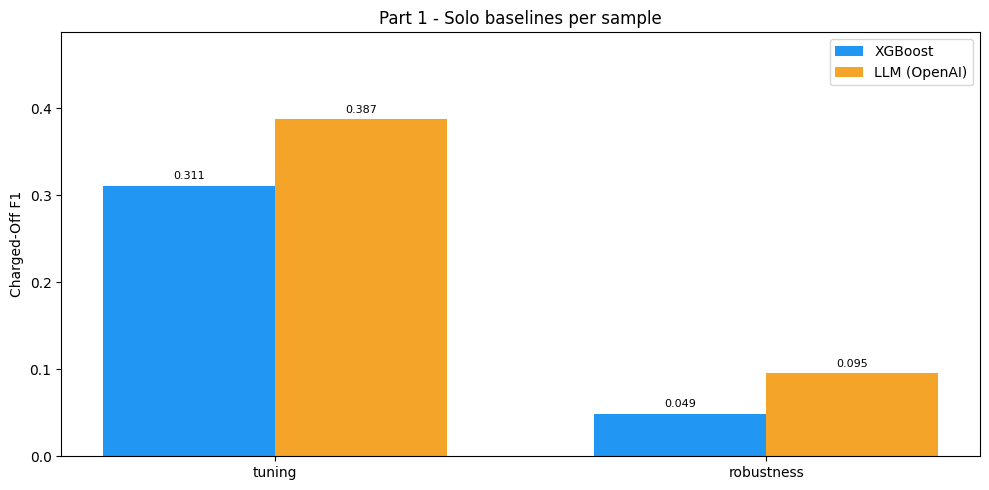

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(SAMPLES)
x = np.arange(len(names)); w = 0.35
xgb_f1 = [f1_score(SAMPLES[n]['y_true'], SAMPLES[n]['xgb_preds'], pos_label=0, zero_division=0) for n in names]
llm_f1 = [f1_score(SAMPLES[n]['y_true'], SAMPLES[n]['llm_binary'], pos_label=0, zero_division=0) for n in names]
b1 = ax.bar(x - w/2, xgb_f1, w, label='XGBoost', color='#2196f3')
b2 = ax.bar(x + w/2, llm_f1, w, label='LLM (OpenAI)', color='#f4a529')
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Charged-Off F1'); ax.set_ylim(0, max(xgb_f1+llm_f1)+0.1)
ax.set_title('Part 1 - Solo baselines per sample'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '03_baselines.png'), dpi=150, bbox_inches='tight'); plt.show()


---
## Part 2 — Hard-label ensemble rules
Boolean combinations of the two binary predictions. Union and intersection need no tuning; the boost and prune rules use a fixed XGB-confidence window (`BOOST_BAND`, `PRUNE_OFF`).

In [8]:
BOOST_BAND = 0.15   # XGB borderline window for the LLM-boost rule
PRUNE_OFF  = 0.25   # XGB high-confidence offset for the LLM-prune rule

def hard_label_preds(S):
    xp, xpr, lb = S['xgb_preds'], S['xgb_probs'], S['llm_binary']
    out = {}
    out['Union (XGB OR LLM)']        = np.where((xp == 0) | (lb == 0), 0, 1)
    out['Intersection (XGB AND LLM)'] = np.where((xp == 0) & (lb == 0), 0, 1)
    borderline = (xpr > xgb_threshold - BOOST_BAND) & (xpr < xgb_threshold + BOOST_BAND)
    boost = xp.copy(); boost[(xp == 1) & (lb == 0) & borderline] = 0
    out['XGB + LLM borderline boost'] = boost
    prune = lb.copy(); prune[(lb == 0) & (xpr >= xgb_threshold + PRUNE_OFF)] = 1
    out['LLM + XGB high-conf prune'] = prune
    return out

hard_rows = []
for name in SAMPLES:
    S = SAMPLES[name]
    hard_rows.append({'sample': name, **metrics_dict('XGBoost (solo)', S['y_true'], S['xgb_preds'])})
    hard_rows.append({'sample': name, **metrics_dict('LLM (solo)',     S['y_true'], S['llm_binary'])})
    for rule, preds in hard_label_preds(S).items():
        hard_rows.append({'sample': name, **metrics_dict(rule, S['y_true'], preds)})

hard_df = pd.DataFrame(hard_rows).set_index(['sample', 'model'])
print(hard_df.to_string())


                                       accuracy  precision_co  recall_co  f1_co
sample     model                                                               
tuning     XGBoost (solo)                  0.69         0.233      0.467  0.311
           LLM (solo)                      0.81         0.375      0.400  0.387
           Union (XGB OR LLM)              0.68         0.242      0.533  0.333
           Intersection (XGB AND LLM)      0.82         0.385      0.333  0.357
           XGB + LLM borderline boost      0.68         0.242      0.533  0.333
           LLM + XGB high-conf prune       0.81         0.375      0.400  0.387
robustness XGBoost (solo)                  0.61         0.031      0.111  0.049
           LLM (solo)                      0.81         0.083      0.111  0.095
           Union (XGB OR LLM)              0.59         0.029      0.111  0.047
           Intersection (XGB AND LLM)      0.83         0.100      0.111  0.105
           XGB + LLM borderline boost   

---
## Part 3 — Soft blend (binary LLM)
`score = α·P_xgb(FP) + (1−α)·P_llm(FP)`, predict FP if `score ≥ threshold`. `P_llm(FP)` is the recycled Phase-1 soft probability (`llm_prob`).

α and threshold are grid-searched on `tuning` only, then locked and applied unchanged to `robustness`.

In [9]:
alphas      = np.round(np.arange(0.00, 1.01, 0.05), 2)
thresh_vals = np.round(np.unique(np.append(np.arange(0.05, 0.96, 0.05), xgb_threshold)), 3)

def soft_preds(S, a, t, llm_key='llm_prob'):
    return ((a * S['xgb_probs'] + (1.0 - a) * S[llm_key].astype(float)) >= t).astype(int)

def tune_soft(S, llm_key='llm_prob'):
    best = (-1, 1.0, 0.5)  # (f1, alpha, threshold)
    for a in alphas:
        for t in thresh_vals:
            f1 = f1_score(S['y_true'], soft_preds(S, a, t, llm_key), pos_label=0, zero_division=0)
            if f1 > best[0]:
                best = (f1, a, t)
    return best

_f1, BLEND_A, BLEND_T = tune_soft(TUNING)
print(f'Tuned on `tuning`: alpha={BLEND_A:.2f}  threshold={BLEND_T:.2f}  (tuning CO-F1={_f1:.3f})')
print(f'  alpha=1 -> XGB only, alpha=0 -> LLM only.  Locking these and applying to all samples:\n')

for name in SAMPLES:
    S = SAMPLES[name]
    p = soft_preds(S, BLEND_A, BLEND_T)
    S['soft_blend_preds'] = p
    m = metrics_dict('soft blend', S['y_true'], p)
    print(f'  {name:11s}  CO-F1={m["f1_co"]:.3f}  recall={m["recall_co"]:.3f}  prec={m["precision_co"]:.3f}  acc={m["accuracy"]:.3f}')


Tuned on `tuning`: alpha=0.15  threshold=0.05  (tuning CO-F1=0.400)
  alpha=1 -> XGB only, alpha=0 -> LLM only.  Locking these and applying to all samples:

  tuning       CO-F1=0.400  recall=0.333  prec=0.500  acc=0.850
  robustness   CO-F1=0.133  recall=0.111  prec=0.167  acc=0.870


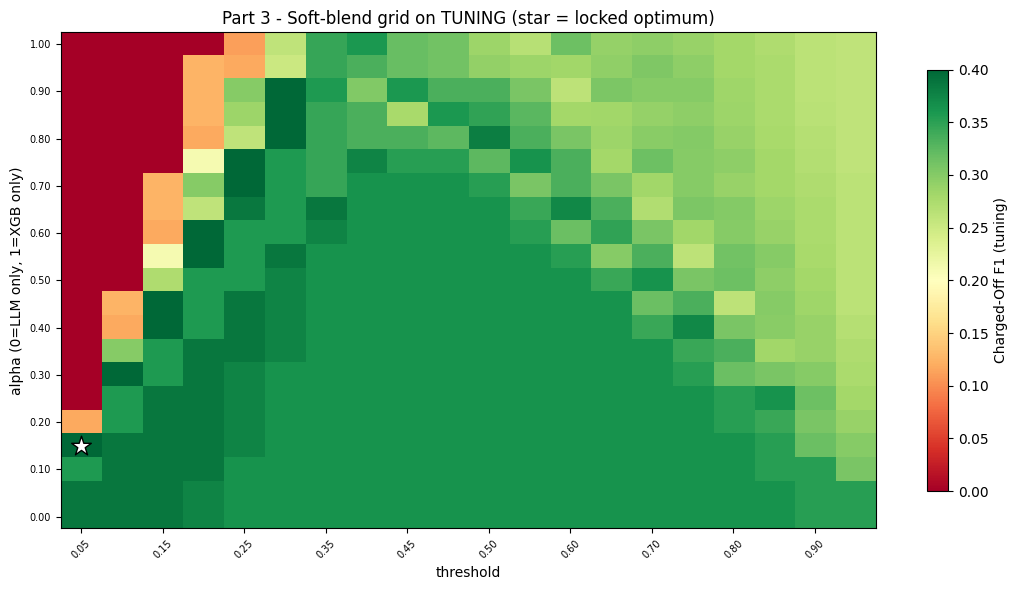

In [10]:
# Heatmap of the tuning-sample grid (where the params were chosen).
grid = np.zeros((len(alphas), len(thresh_vals)))
for ia, a in enumerate(alphas):
    for it, t in enumerate(thresh_vals):
        grid[ia, it] = f1_score(TUNING['y_true'], soft_preds(TUNING, a, t), pos_label=0, zero_division=0)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(grid, aspect='auto', origin='lower', cmap='RdYlGn',
               vmin=max(0.0, grid.min()), vmax=grid.max())
plt.colorbar(im, ax=ax, label='Charged-Off F1 (tuning)', shrink=0.85)
sc = max(1, len(thresh_vals)//10); sr = max(1, len(alphas)//10)
ax.set_xticks(range(0, len(thresh_vals), sc)); ax.set_xticklabels([f'{t:.2f}' for t in thresh_vals[::sc]], rotation=45, fontsize=7)
ax.set_yticks(range(0, len(alphas), sr));      ax.set_yticklabels([f'{a:.2f}' for a in alphas[::sr]], fontsize=7)
ax.set_xlabel('threshold'); ax.set_ylabel('alpha (0=LLM only, 1=XGB only)')
ax.set_title('Part 3 - Soft-blend grid on TUNING (star = locked optimum)')
ax.scatter([list(thresh_vals).index(BLEND_T)], [list(alphas).index(BLEND_A)],
           color='white', edgecolor='black', s=220, marker='*', zorder=5)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '03_soft_blend_heatmap.png'), dpi=150, bbox_inches='tight'); plt.show()


---
## Part 4 — Confidence-gated consultation
XGBoost decides alone when its probability is far from the boundary; the LLM is consulted only
for borderline loans. **The band width is tuned on `tuning`**, then locked.

```
P_xgb < threshold - band  -> CO     (XGB confident)
P_xgb >= threshold + band -> FP     (XGB confident)
otherwise                 -> LLM binary prediction
```


In [11]:
band_widths = np.round(np.arange(0.00, 0.511, 0.01), 3)

def gate_preds(S, band):
    lo = max(0.0, xgb_threshold - band); hi = min(1.0, xgb_threshold + band)
    xpr, lb = S['xgb_probs'], S['llm_binary']
    return np.array([0 if xpr[i] < lo else (1 if xpr[i] >= hi else int(lb[i])) for i in range(len(xpr))]), lo, hi

def gate_pct_llm(S, band):
    lo = max(0.0, xgb_threshold - band); hi = min(1.0, xgb_threshold + band)
    xpr = S['xgb_probs']
    return float(np.mean((xpr >= lo) & (xpr < hi)) * 100)

# Tune band on tuning.
tune_curve = []
best_band, best_band_f1 = 0.0, -1.0
for band in band_widths:
    p, _, _ = gate_preds(TUNING, band)
    f1 = f1_score(TUNING['y_true'], p, pos_label=0, zero_division=0)
    tune_curve.append((band, f1, gate_pct_llm(TUNING, band)))
    if f1 > best_band_f1:
        best_band_f1, best_band = f1, band

GATE_BAND = best_band
print(f'Tuned on `tuning`: band=+/-{GATE_BAND:.3f}  (tuning CO-F1={best_band_f1:.3f}, '
      f'{gate_pct_llm(TUNING, GATE_BAND):.0f}% sent to LLM)\n')

for name in SAMPLES:
    S = SAMPLES[name]
    p, lo, hi = gate_preds(S, GATE_BAND)
    S['gate_preds'] = p
    m = metrics_dict('gate', S['y_true'], p)
    print(f'  {name:11s}  CO-F1={m["f1_co"]:.3f}  recall={m["recall_co"]:.3f}  '
          f'prec={m["precision_co"]:.3f}  LLM-consulted={gate_pct_llm(S, GATE_BAND):.0f}%')


Tuned on `tuning`: band=+/-0.070  (tuning CO-F1=0.400, 18% sent to LLM)

  tuning       CO-F1=0.400  recall=0.533  prec=0.320  LLM-consulted=18%
  robustness   CO-F1=0.057  recall=0.111  prec=0.038  LLM-consulted=27%


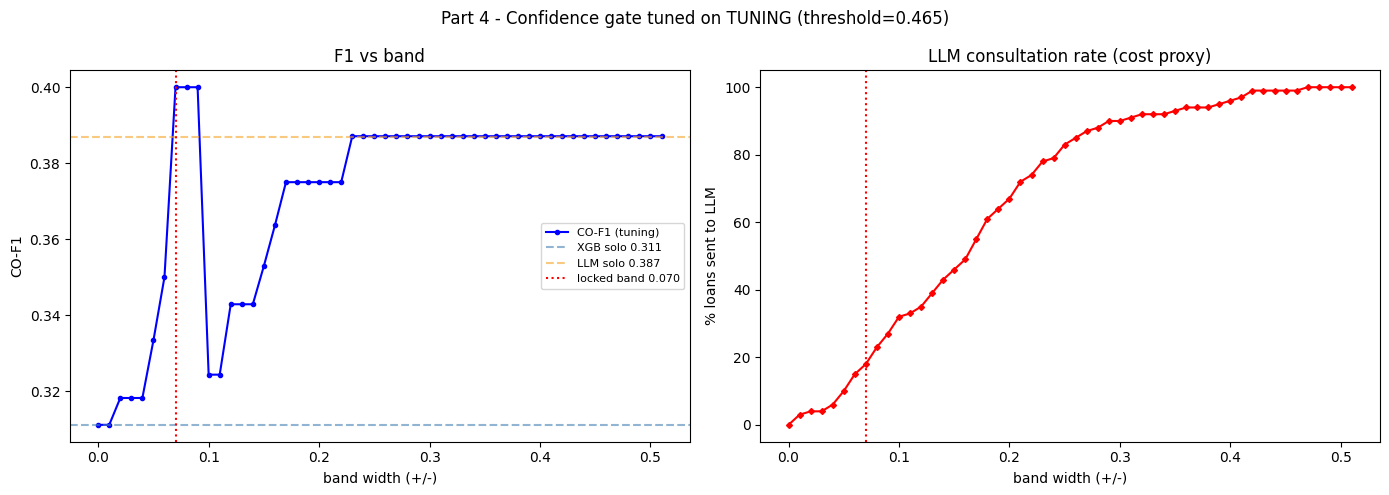

In [12]:
tc = np.array(tune_curve)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Part 4 - Confidence gate tuned on TUNING (threshold={xgb_threshold:.3f})', fontsize=12)
ax1.plot(tc[:, 0], tc[:, 1], 'b-o', markersize=3, label='CO-F1 (tuning)')
ax1.axhline(xgb_m['f1_co'], color='steelblue', ls='--', alpha=0.6, label=f"XGB solo {xgb_m['f1_co']:.3f}")
ax1.axhline(llm_m['f1_co'], color='#f4a529', ls='--', alpha=0.6, label=f"LLM solo {llm_m['f1_co']:.3f}")
ax1.axvline(GATE_BAND, color='red', ls=':', label=f'locked band {GATE_BAND:.3f}')
ax1.set_xlabel('band width (+/-)'); ax1.set_ylabel('CO-F1'); ax1.set_title('F1 vs band'); ax1.legend(fontsize=8)
ax2.plot(tc[:, 0], tc[:, 2], 'r-D', markersize=3)
ax2.axvline(GATE_BAND, color='red', ls=':')
ax2.set_xlabel('band width (+/-)'); ax2.set_ylabel('% loans sent to LLM'); ax2.set_title('LLM consultation rate (cost proxy)')
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '03_confidence_gate.png'), dpi=150, bbox_inches='tight'); plt.show()


---
## Part 5 — Risk-score blend (5A)
The numeric 5A risk score (0–10, from OpenAI) becomes a probability analog and blends *continuously* with
XGBoost — a genuinely soft blend (vs. Part 3's binary term).

```
p_fp = 1 − risk_score/10          # high risk -> low P(Fully Paid)
score = α·P_xgb(FP) + (1−α)·p_fp
```


In [13]:
def add_pfp(S):
    S['p_fp_5a'] = 1.0 - S['score_5a'] / 10.0

for name in SAMPLES:
    add_pfp(SAMPLES[name])

def soft_preds_pfp(S, a, t, key):
    return ((a * S['xgb_probs'] + (1.0 - a) * S[key]) >= t).astype(int)

def tune_pfp(S, key):
    best = (-1, 1.0, 0.5)
    for a in alphas:
        for t in thresh_vals:
            f1 = f1_score(S['y_true'], soft_preds_pfp(S, a, t, key), pos_label=0, zero_division=0)
            if f1 > best[0]:
                best = (f1, a, t)
    return best

RISK_PARAMS = {}
for key, lbl in [('p_fp_5a', '5A desc-only')]:
    f1, a, t = tune_pfp(TUNING, key)
    RISK_PARAMS[key] = (a, t)
    print(f'{lbl:18s} tuned on `tuning`: alpha={a:.2f} threshold={t:.2f} (tuning CO-F1={f1:.3f})')
    for name in SAMPLES:
        S = SAMPLES[name]
        p = soft_preds_pfp(S, a, t, key)
        S[f'{key}_preds'] = p
        m = metrics_dict(lbl, S['y_true'], p)
        print(f'    {name:11s} CO-F1={m["f1_co"]:.3f} recall={m["recall_co"]:.3f} prec={m["precision_co"]:.3f}')
    print()

# How novel is the text signal vs XGBoost? (correlation of 5A risk with P(CO) on tuning)
r5a = np.corrcoef(TUNING['score_5a'], 1 - TUNING['xgb_probs'])[0, 1]
print(f'[tuning] corr(5A risk, XGB P(CO))={r5a:+.3f} (low = novel text signal)')

5A desc-only       tuned on `tuning`: alpha=0.60 threshold=0.40 (tuning CO-F1=0.400)
    tuning      CO-F1=0.400 recall=0.400 prec=0.400
    robustness  CO-F1=0.087 recall=0.111 prec=0.071

[tuning] corr(5A risk, XGB P(CO))=+0.297 (low = novel text signal)


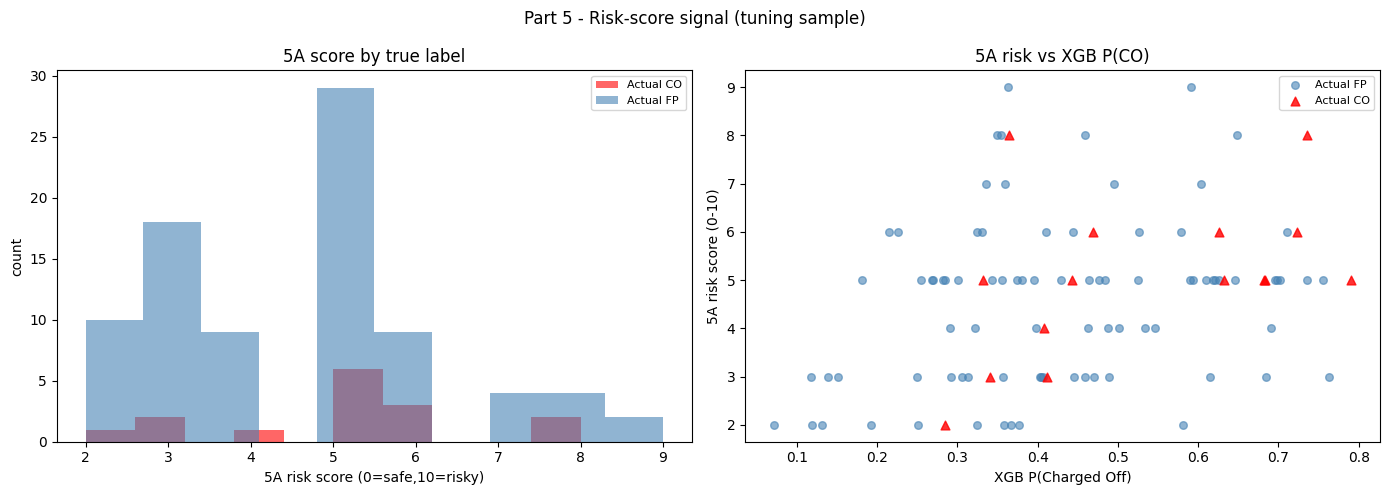

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part 5 - Risk-score signal (tuning sample)', fontsize=12)
yt = TUNING['y_true']
ax1.hist(TUNING['score_5a'][yt == 0], bins=10, alpha=0.6, color='red', label='Actual CO')
ax1.hist(TUNING['score_5a'][yt == 1], bins=10, alpha=0.6, color='steelblue', label='Actual FP')
ax1.set_xlabel('5A risk score (0=safe,10=risky)'); ax1.set_ylabel('count'); ax1.set_title('5A score by true label'); ax1.legend(fontsize=8)
ax2.scatter(1 - TUNING['xgb_probs'][yt == 1], TUNING['score_5a'][yt == 1], alpha=0.6, color='steelblue', label='Actual FP', s=30)
ax2.scatter(1 - TUNING['xgb_probs'][yt == 0], TUNING['score_5a'][yt == 0], alpha=0.8, color='red', marker='^', label='Actual CO', s=40)
ax2.set_xlabel('XGB P(Charged Off)'); ax2.set_ylabel('5A risk score (0-10)')
ax2.set_title('5A risk vs XGB P(CO)'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '03_risk_scores.png'), dpi=150, bbox_inches='tight'); plt.show()

---
## Final leaderboard
Every strategy uses parameters locked from `tuning`. The table shows CO-F1 on `tuning` (in-sample) and `robustness` (validation); the winning strategy is chosen by `robustness`. The held-out `test_batch` is not scored here. It is touched once in Phase 4, which applies the locked params written below.

In [ ]:
def all_strategy_preds(S):
    p = {
        'XGBoost (solo)': S['xgb_preds'],
        'LLM (solo)':     S['llm_binary'],
        'Soft blend (binary)':   S['soft_blend_preds'],
        'Confidence gate':       S['gate_preds'],
        '5A risk blend (desc)':  S['p_fp_5a_preds'],
    }
    p.update(hard_label_preds(S))
    return p

# CO-F1 of every strategy on every loaded sample (tuning + robustness only).
# test_batch is intentionally NOT loaded in this notebook — it is held out and
# evaluated once in Phase 4 by applying the locked params from the next cell.
f1_table = {}
for name in SAMPLES:
    S = SAMPLES[name]
    f1_table[name] = {strat: round(f1_score(S['y_true'], preds, pos_label=0, zero_division=0), 3)
                      for strat, preds in all_strategy_preds(S).items()}

lb = pd.DataFrame(f1_table)  # rows=strategy, cols=sample
lb = lb[['tuning', 'robustness']].sort_values('robustness', ascending=False)
print('Charged-Off F1 by strategy and sample (sorted by robustness/validation):\n')
print(lb.to_string())

# Strategy selection is on robustness (validation) — never on test.
winner = lb.index[0]
print(f'\n=== Winning strategy (by robustness/validation): {winner} ===')
print(f'  tuning CO-F1     : {lb.loc[winner, "tuning"]:.3f}')
print(f'  robustness CO-F1 : {lb.loc[winner, "robustness"]:.3f}  (validation — used to pick)')
print(f'\n  vs XGBoost solo (robustness): {lb.loc["XGBoost (solo)", "robustness"]:.3f}  '
      f'(delta {lb.loc[winner, "robustness"] - lb.loc["XGBoost (solo)", "robustness"]:+.3f})')
print(f'  vs LLM solo (robustness)    : {lb.loc["LLM (solo)", "robustness"]:.3f}  '
      f'(delta {lb.loc[winner, "robustness"] - lb.loc["LLM (solo)", "robustness"]:+.3f})')
print('\nTest-set CO-F1 is deliberately not computed here — test_batch is held out and')
print('evaluated once in Phase 4 using the locked params saved below.')

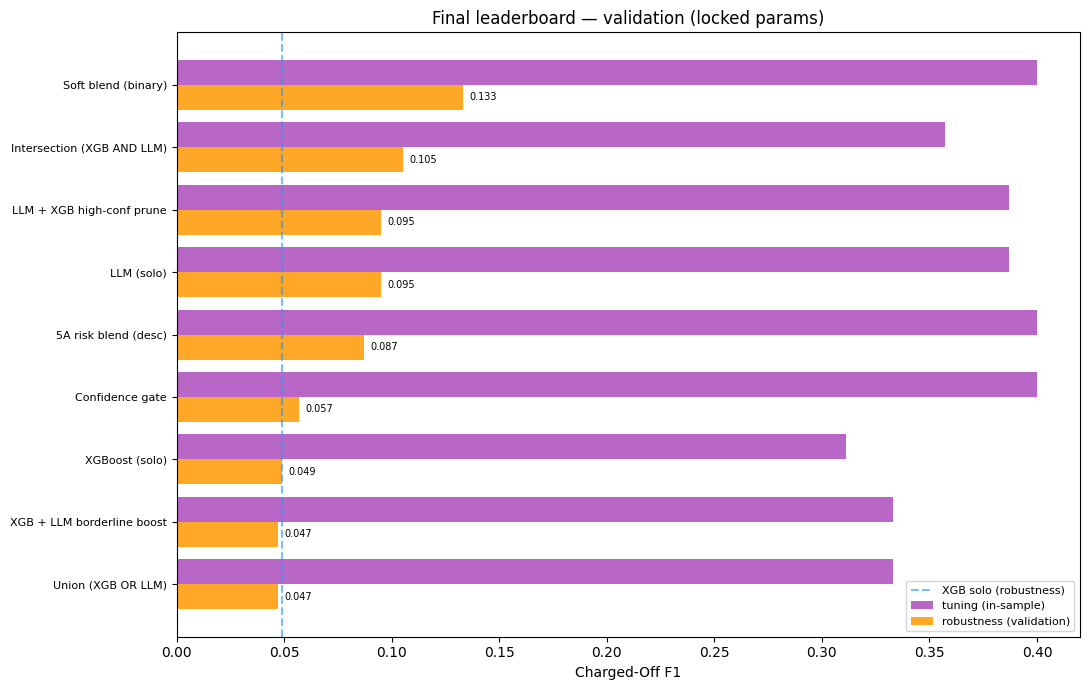

In [16]:
fig, ax = plt.subplots(figsize=(11, 7))
order = lb.sort_values('robustness').index
y = np.arange(len(order)); h = 0.4
ax.barh(y + h/2, lb.loc[order, 'tuning'],     h, color='#9c27b0', alpha=0.7,  label='tuning (in-sample)')
ax.barh(y - h/2, lb.loc[order, 'robustness'], h, color='#ff9800', alpha=0.85, label='robustness (validation)')
for yi, strat in enumerate(order):
    ax.text(lb.loc[strat, 'robustness'] + 0.003, yi - h/2,
            f"{lb.loc[strat, 'robustness']:.3f}", va='center', fontsize=7)
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8)
ax.axvline(lb.loc['XGBoost (solo)', 'robustness'], color='#2196f3', ls='--', alpha=0.6, label='XGB solo (robustness)')
ax.set_xlabel('Charged-Off F1'); ax.set_title('Final leaderboard — validation (locked params)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, '03_leaderboard.png'), dpi=150, bbox_inches='tight'); plt.show()

In [17]:
# Persist results.
os.makedirs(RESULTS_DIR, exist_ok=True)
lb.to_csv(os.path.join(RESULTS_DIR, '03_blend_leaderboard.csv'))

locked = pd.DataFrame([
    {'strategy': 'soft blend (binary)', 'alpha': BLEND_A, 'threshold': BLEND_T, 'extra': ''},
    {'strategy': 'confidence gate',     'alpha': '',      'threshold': xgb_threshold, 'extra': f'band={GATE_BAND}'},
    {'strategy': '5A risk blend',       'alpha': RISK_PARAMS['p_fp_5a'][0], 'threshold': RISK_PARAMS['p_fp_5a'][1], 'extra': ''},
])
locked.to_csv(os.path.join(RESULTS_DIR, '03_locked_params.csv'), index=False)

print('Saved:')
print('  03_blend_leaderboard.csv   - CO-F1 by strategy x sample (tuning + robustness)')
print('  03_locked_params.csv       - hyper-parameters tuned on `tuning`')
print('  03_openai_*.csv            - cached per-loan signals (binary recycled + 5A) per sample')
print('  03_baselines.png / 03_soft_blend_heatmap.png / 03_confidence_gate.png /')
print('  03_risk_scores.png / 03_leaderboard.png')
print(f'\nAll in: {RESULTS_DIR}')

Saved:
  03_blend_leaderboard.csv   - CO-F1 by strategy x sample (tuning + robustness)
  03_locked_params.csv       - hyper-parameters tuned on `tuning`
  03_openai_*.csv            - cached per-loan signals (binary recycled + 5A) per sample
  03_baselines.png / 03_soft_blend_heatmap.png / 03_confidence_gate.png /
  03_risk_scores.png / 03_leaderboard.png

All in: /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm


---
## Appendix — Sentence embeddings (optional)
Encode borrower descriptions with `all-MiniLM-L6-v2`, reduce with PCA (unsupervised), and blend the most label-correlated component with XGBoost. The PC-blend weight is tuned on `tuning` and applied to `robustness`. Skips cleanly if `sentence-transformers` is not installed.

In [ ]:
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.decomposition import PCA
    _ok = True
except ImportError:
    print('[SKIP] pip install sentence-transformers to run the embeddings appendix.')
    _ok = False

if _ok:
    enc = SentenceTransformer('all-MiniLM-L6-v2')

    def embed_pcs(df, pca=None):
        col = df['desc'] if 'desc' in df.columns else pd.Series([''] * len(df))
        descs = [str(d) if (pd.notna(d) and str(d).strip()) else '' for d in col]
        emb = enc.encode(descs, batch_size=32, show_progress_bar=False)
        if pca is None:
            pca = PCA(n_components=10, random_state=42).fit(emb)
        return pca.transform(emb), pca

    # Fit PCA + choose PC + tune weight on TUNING only.
    pcs_tune, pca = embed_pcs(TUNING['df'])
    rs = [np.corrcoef(pcs_tune[:, k], TUNING['y_true'])[0, 1] for k in range(pcs_tune.shape[1])]
    best_k = int(np.argmax(np.abs(rs))); sign = -1 if rs[best_k] < 0 else 1
    print(f'Most label-correlated PC on tuning: PC{best_k+1} (r={rs[best_k]:+.3f})')

    def pc_norm(pcs):
        v = sign * pcs[:, best_k]
        return (v - v.min()) / (v.max() - v.min() + 1e-9)

    pcn_tune = pc_norm(pcs_tune)
    best = (-1, 0.0, 0.5)
    for w in np.round(np.arange(0.0, 0.31, 0.02), 2):
        for t in thresh_vals:
            pr = (((1 - w) * TUNING['xgb_probs'] + w * pcn_tune) >= t).astype(int)
            f1 = f1_score(TUNING['y_true'], pr, pos_label=0, zero_division=0)
            if f1 > best[0]:
                best = (f1, w, t)
    _, PC_W, PC_T = best
    print(f'Tuned PC-blend: weight={PC_W:.2f} threshold={PC_T:.2f} (tuning CO-F1={best[0]:.3f})\n')

    for name in SAMPLES:
        S = SAMPLES[name]
        pcs, _ = embed_pcs(S['df'], pca=pca)
        pr = (((1 - PC_W) * S['xgb_probs'] + PC_W * pc_norm(pcs)) >= PC_T).astype(int)
        f1 = f1_score(S['y_true'], pr, pos_label=0, zero_division=0)
        print(f'  {name:11s} embedding-blend CO-F1={f1:.3f}  (XGB solo {f1_score(S["y_true"], S["xgb_preds"], pos_label=0, zero_division=0):.3f})')
    print('\nNote: PCA is fit on tuning only and reused (transform) for the other samples, so there')
    print('is no leakage. test_batch is not processed here — Phase 4 would reuse this tuning-fit PCA.')